# 01 — DEM Particle Generation and Gravity Settlement

This notebook creates a two-dimensional representative sand specimen.

The model includes:

- circular sand particles;
- particle-size variation;
- particle-particle contact;
- particle-wall contact;
- normal elastic contact force;
- tangential friction force;
- contact damping;
- particle rotation;
- gravity deposition;
- kinetic-energy monitoring;
- coordination-number calculation;
- saving of the settled packing.

This is a simplified educational DEM implementation. The contact parameters are
assumed demonstration values and have not yet been calibrated against laboratory
tests for the sand layer beneath the dike.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.collections import PatchCollection, LineCollection
from matplotlib.patches import Circle
from scipy.spatial import cKDTree

np.set_printoptions(precision=5, suppress=True)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# The notebook is assumed to be inside:
# dike_fem_dem_project/notebooks/

current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_directory = current_directory.parent
else:
    project_directory = current_directory

results_directory = project_directory / "results"
figure_directory = results_directory / "figures"
csv_directory = results_directory / "csv"
restart_directory = results_directory / "restart"

for folder in [
    results_directory,
    figure_directory,
    csv_directory,
    restart_directory,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project directory:", project_directory)
print("Results directory:", results_directory)

Project directory: C:\Users\duaas\dike_fem_dem_project
Results directory: C:\Users\duaas\dike_fem_dem_project\results


In [3]:
# ============================================================
# SPECIMEN GEOMETRY
# ============================================================

box_width = 0.12       # m
box_height = 0.16      # m

# ============================================================
# PARTICLE PROPERTIES
# ============================================================

number_of_particles = 120

minimum_radius = 0.0035    # m
maximum_radius = 0.0055    # m

particle_density = 2650.0  # kg/m3
particle_thickness = 0.01  # m

# ============================================================
# CONTACT PARAMETERS
# ============================================================

# Softer parameters are used only to generate the stable
# gravity-deposited packing efficiently.
normal_stiffness = 2.0e4       # N/m
tangential_stiffness = 8.0e3   # N/m

normal_damping = 4.0           # N s/m
tangential_damping = 1.0       # N s/m

particle_friction = 0.50
wall_friction = 0.40

# ============================================================
# GRAVITY AND NUMERICAL PARAMETERS
# ============================================================

gravity = 9.81                 # m/s2

time_step = 2.0e-5             # s
maximum_steps = 30000

global_velocity_damping = 0.9995

output_interval = 100
equilibrium_check_interval = 250

kinetic_energy_tolerance = 1.0e-7
maximum_velocity_tolerance = 2.0e-3

required_equilibrium_checks = 8

random_seed = 42
rng = np.random.default_rng(random_seed)

# ============================================================
# PRINT PARAMETER SUMMARY
# ============================================================

print("DEM parameters defined.")
print("Number of particles:", number_of_particles)
print("Normal stiffness:", normal_stiffness, "N/m")
print("Tangential stiffness:", tangential_stiffness, "N/m")
print("Normal damping:", normal_damping, "N s/m")
print("Tangential damping:", tangential_damping, "N s/m")
print("Time step:", time_step, "s")
print("Maximum steps:", maximum_steps)
print(
    "Maximum simulated time:",
    maximum_steps * time_step,
    "s",
)

DEM parameters defined.
Number of particles: 120
Normal stiffness: 20000.0 N/m
Tangential stiffness: 8000.0 N/m
Normal damping: 4.0 N s/m
Tangential damping: 1.0 N s/m
Time step: 2e-05 s
Maximum steps: 30000
Maximum simulated time: 0.6000000000000001 s


In [4]:
def calculate_particle_mass(radius):
    """
    Calculate particle mass assuming a cylindrical particle
    with a defined out-of-plane thickness.
    """
    volume = np.pi * radius**2 * particle_thickness
    return particle_density * volume


def generate_non_overlapping_particles(
    number_of_particles,
    box_width,
    box_height,
    minimum_radius,
    maximum_radius,
    rng,
    maximum_attempts=500000,
):
    """
    Generate particles using random sequential insertion.

    Particles are initially placed above the bottom boundary
    without overlap.
    """

    radii = rng.uniform(
        minimum_radius,
        maximum_radius,
        number_of_particles,
    )

    # Place larger particles first to make insertion easier.
    radii = np.sort(radii)[::-1]

    positions = []
    accepted_radii = []

    attempt = 0

    while len(positions) < number_of_particles and attempt < maximum_attempts:
        attempt += 1

        radius = radii[len(positions)]

        x_candidate = rng.uniform(
            radius,
            box_width - radius,
        )

        # Generate the initial packing mainly in the upper portion
        # of the box so that gravity deposition can be observed.
        y_candidate = rng.uniform(
            0.04 + radius,
            box_height - radius,
        )

        candidate = np.array([x_candidate, y_candidate])

        acceptable = True

        for existing_position, existing_radius in zip(
            positions,
            accepted_radii,
        ):
            centre_distance = np.linalg.norm(
                candidate - existing_position
            )

            minimum_distance = 1.03 * (
                radius + existing_radius
            )

            if centre_distance < minimum_distance:
                acceptable = False
                break

        if acceptable:
            positions.append(candidate)
            accepted_radii.append(radius)

    if len(positions) < number_of_particles:
        raise RuntimeError(
            f"Only {len(positions)} particles could be generated. "
            "Increase the box size or reduce the particle number."
        )

    return (
        np.array(positions, dtype=float),
        np.array(accepted_radii, dtype=float),
    )


positions, radii = generate_non_overlapping_particles(
    number_of_particles=number_of_particles,
    box_width=box_width,
    box_height=box_height,
    minimum_radius=minimum_radius,
    maximum_radius=maximum_radius,
    rng=rng,
)

velocities = np.zeros_like(positions)
angular_velocities = np.zeros(number_of_particles)
angles = np.zeros(number_of_particles)

masses = calculate_particle_mass(radii)

moments_of_inertia = 0.5 * masses * radii**2

initial_positions = positions.copy()

print("Initial particle packing generated.")
print("Minimum particle radius:", radii.min(), "m")
print("Maximum particle radius:", radii.max(), "m")
print("Total particle mass:", masses.sum(), "kg")

Initial particle packing generated.
Minimum particle radius: 0.003514724539502011 m
Maximum particle radius: 0.0054512447032735115 m
Total particle mass: 0.20504091942253838 kg


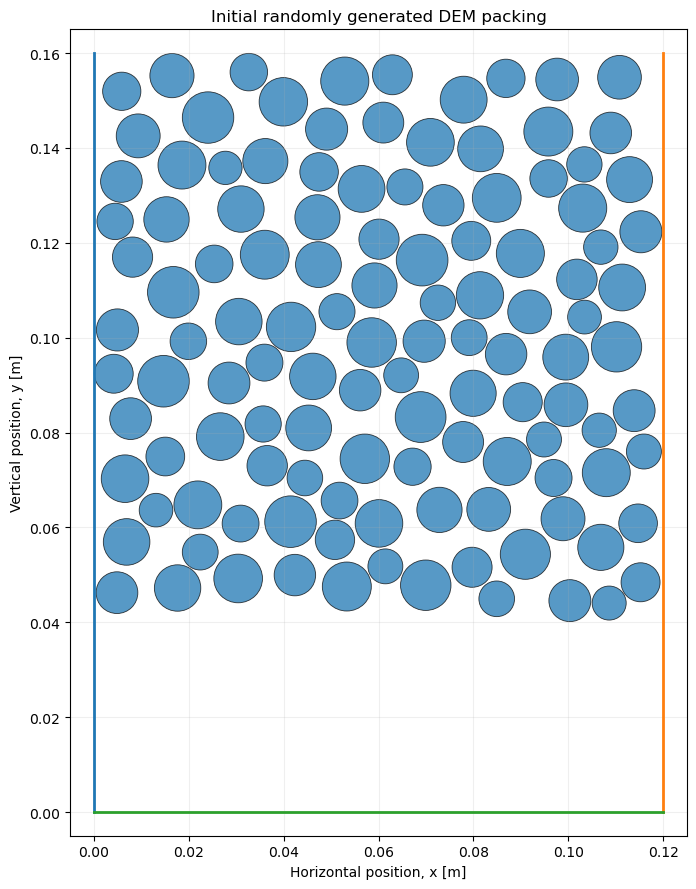

In [5]:
def plot_particles(
    positions,
    radii,
    box_width,
    box_height,
    title,
    displacement=None,
    save_path=None,
):
    fig, ax = plt.subplots(figsize=(8, 9))

    circles = [
        Circle(
            (positions[i, 0], positions[i, 1]),
            radii[i],
        )
        for i in range(len(radii))
    ]

    collection = PatchCollection(
        circles,
        edgecolor="black",
        linewidth=0.6,
        alpha=0.75,
    )

    if displacement is not None:
        displacement_magnitude = np.linalg.norm(
            displacement,
            axis=1,
        )

        collection.set_array(displacement_magnitude)
        figure_collection = ax.add_collection(collection)

        colorbar = plt.colorbar(
            figure_collection,
            ax=ax,
        )
        colorbar.set_label("Particle displacement magnitude [m]")
    else:
        ax.add_collection(collection)

    ax.plot(
        [0, 0],
        [0, box_height],
        linewidth=2,
    )

    ax.plot(
        [box_width, box_width],
        [0, box_height],
        linewidth=2,
    )

    ax.plot(
        [0, box_width],
        [0, 0],
        linewidth=2,
    )

    ax.set_xlim(-0.005, box_width + 0.005)
    ax.set_ylim(-0.005, box_height + 0.005)

    ax.set_aspect("equal")
    ax.set_xlabel("Horizontal position, x [m]")
    ax.set_ylabel("Vertical position, y [m]")
    ax.set_title(title)
    ax.grid(alpha=0.2)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()


plot_particles(
    positions=positions,
    radii=radii,
    box_width=box_width,
    box_height=box_height,
    title="Initial randomly generated DEM packing",
    save_path=figure_directory / "01_initial_dem_packing.png",
)

In [6]:
def limit_force_by_coulomb_friction(
    tangential_force,
    normal_force_magnitude,
    friction_coefficient,
):
    """
    Limit the tangential force according to the Coulomb criterion.
    """

    maximum_tangential_force = (
        friction_coefficient * normal_force_magnitude
    )

    tangential_magnitude = np.linalg.norm(tangential_force)

    if (
        tangential_magnitude > maximum_tangential_force
        and tangential_magnitude > 0.0
    ):
        tangential_force = (
            tangential_force
            / tangential_magnitude
            * maximum_tangential_force
        )

    return tangential_force


def calculate_particle_contacts(
    positions,
    velocities,
    angular_velocities,
    radii,
    normal_stiffness,
    tangential_stiffness,
    normal_damping,
    tangential_damping,
    particle_friction,
    time_step,
    tangential_history,
):
    """
    Calculate particle-particle contact forces.

    A linear normal spring-dashpot law and a simplified
    tangential spring-dashpot law are used.
    """

    number_of_particles = len(radii)

    forces = np.zeros((number_of_particles, 2))
    torques = np.zeros(number_of_particles)

    active_contacts = set()
    contact_information = []

    search_radius = 2.05 * radii.max()

    tree = cKDTree(positions)

    candidate_pairs = tree.query_pairs(
        r=search_radius
    )

    for i, j in candidate_pairs:
        relative_position = positions[j] - positions[i]

        distance = np.linalg.norm(relative_position)

        combined_radius = radii[i] + radii[j]
        overlap = combined_radius - distance

        if overlap <= 0.0 or distance <= 1.0e-12:
            continue

        contact_key = (min(i, j), max(i, j))
        active_contacts.add(contact_key)

        normal_vector = relative_position / distance

        tangential_vector = np.array(
            [-normal_vector[1], normal_vector[0]]
        )

        relative_velocity = velocities[j] - velocities[i]

        normal_relative_velocity = np.dot(
            relative_velocity,
            normal_vector,
        )

        # Rotational motion contributes to relative tangential velocity.
        tangential_relative_velocity = (
            np.dot(relative_velocity, tangential_vector)
            - angular_velocities[i] * radii[i]
            - angular_velocities[j] * radii[j]
        )

        elastic_normal_force = normal_stiffness * overlap

        damping_normal_force = (
            -normal_damping * normal_relative_velocity
        )

        normal_force_magnitude = max(
            0.0,
            elastic_normal_force + damping_normal_force,
        )

        normal_force = (
            normal_force_magnitude * normal_vector
        )

        previous_tangential_displacement = (
            tangential_history.get(contact_key, 0.0)
        )

        updated_tangential_displacement = (
            previous_tangential_displacement
            + tangential_relative_velocity * time_step
        )

        trial_tangential_force_scalar = (
            -tangential_stiffness
            * updated_tangential_displacement
            - tangential_damping
            * tangential_relative_velocity
        )

        maximum_tangential_force = (
            particle_friction * normal_force_magnitude
        )

        tangential_force_scalar = np.clip(
            trial_tangential_force_scalar,
            -maximum_tangential_force,
            maximum_tangential_force,
        )

        # Correct the spring displacement when sliding occurs.
        if tangential_stiffness > 0.0:
            corrected_tangential_displacement = -(
                tangential_force_scalar
                + tangential_damping
                * tangential_relative_velocity
            ) / tangential_stiffness
        else:
            corrected_tangential_displacement = 0.0

        tangential_history[contact_key] = (
            corrected_tangential_displacement
        )

        tangential_force = (
            tangential_force_scalar * tangential_vector
        )

        total_contact_force = (
            normal_force + tangential_force
        )

        forces[i] -= total_contact_force
        forces[j] += total_contact_force

        torque_i = (
            -radii[i] * tangential_force_scalar
        )

        torque_j = (
            -radii[j] * tangential_force_scalar
        )

        torques[i] += torque_i
        torques[j] += torque_j

        contact_information.append(
            {
                "particle_i": i,
                "particle_j": j,
                "normal_force": normal_force_magnitude,
                "tangential_force": abs(
                    tangential_force_scalar
                ),
                "overlap": overlap,
            }
        )

    # Remove tangential histories belonging to inactive contacts.
    inactive_contacts = (
        set(tangential_history.keys()) - active_contacts
    )

    for contact_key in inactive_contacts:
        tangential_history.pop(contact_key, None)

    return (
        forces,
        torques,
        contact_information,
        tangential_history,
    )


def calculate_wall_contacts(
    positions,
    velocities,
    angular_velocities,
    radii,
    box_width,
    normal_stiffness,
    tangential_stiffness,
    normal_damping,
    tangential_damping,
    wall_friction,
):
    """
    Calculate contact forces from the left wall,
    right wall and bottom wall.

    The top boundary is left open during gravity deposition.
    """

    number_of_particles = len(radii)

    forces = np.zeros((number_of_particles, 2))
    torques = np.zeros(number_of_particles)

    wall_contact_count = 0
    maximum_wall_overlap = 0.0

    for i in range(number_of_particles):
        x, y = positions[i]
        vx, vy = velocities[i]
        radius = radii[i]

        wall_definitions = []

        # Left wall
        left_overlap = radius - x

        if left_overlap > 0.0:
            wall_definitions.append(
                (
                    left_overlap,
                    np.array([1.0, 0.0]),
                    np.array([0.0, 1.0]),
                )
            )

        # Right wall
        right_overlap = x + radius - box_width

        if right_overlap > 0.0:
            wall_definitions.append(
                (
                    right_overlap,
                    np.array([-1.0, 0.0]),
                    np.array([0.0, 1.0]),
                )
            )

        # Bottom wall
        bottom_overlap = radius - y

        if bottom_overlap > 0.0:
            wall_definitions.append(
                (
                    bottom_overlap,
                    np.array([0.0, 1.0]),
                    np.array([1.0, 0.0]),
                )
            )

        for overlap, normal_vector, tangential_vector in wall_definitions:
            wall_contact_count += 1

            maximum_wall_overlap = max(
                maximum_wall_overlap,
                overlap,
            )

            normal_velocity = np.dot(
                velocities[i],
                normal_vector,
            )

            tangential_velocity = (
                np.dot(velocities[i], tangential_vector)
                - angular_velocities[i] * radius
            )

            normal_force_magnitude = max(
                0.0,
                normal_stiffness * overlap
                - normal_damping * normal_velocity,
            )

            tangential_force_scalar = (
                -tangential_damping * tangential_velocity
            )

            maximum_tangential_force = (
                wall_friction * normal_force_magnitude
            )

            tangential_force_scalar = np.clip(
                tangential_force_scalar,
                -maximum_tangential_force,
                maximum_tangential_force,
            )

            normal_force = (
                normal_force_magnitude * normal_vector
            )

            tangential_force = (
                tangential_force_scalar * tangential_vector
            )

            forces[i] += normal_force + tangential_force

            torques[i] += (
                -radius * tangential_force_scalar
            )

    return (
        forces,
        torques,
        wall_contact_count,
        maximum_wall_overlap,
    )


print("DEM contact functions defined.")

DEM contact functions defined.


In [7]:
# Reinitialise the dynamic variables before settlement.
positions = initial_positions.copy()
velocities = np.zeros_like(positions)
angular_velocities = np.zeros(number_of_particles)
angles = np.zeros(number_of_particles)

tangential_history = {}

time_history = []
kinetic_energy_history = []
maximum_velocity_history = []
coordination_number_history = []
contact_count_history = []
maximum_overlap_history = []

consecutive_equilibrium_checks = 0
equilibrium_reached = False

last_contact_information = []

print("Starting gravity-settlement simulation...")

for step in range(maximum_steps):

    particle_forces = np.zeros_like(positions)
    particle_torques = np.zeros(number_of_particles)

    # Gravity force
    particle_forces[:, 1] -= masses * gravity

    (
        contact_forces,
        contact_torques,
        contact_information,
        tangential_history,
    ) = calculate_particle_contacts(
        positions=positions,
        velocities=velocities,
        angular_velocities=angular_velocities,
        radii=radii,
        normal_stiffness=normal_stiffness,
        tangential_stiffness=tangential_stiffness,
        normal_damping=normal_damping,
        tangential_damping=tangential_damping,
        particle_friction=particle_friction,
        time_step=time_step,
        tangential_history=tangential_history,
    )

    (
        wall_forces,
        wall_torques,
        wall_contact_count,
        maximum_wall_overlap,
    ) = calculate_wall_contacts(
        positions=positions,
        velocities=velocities,
        angular_velocities=angular_velocities,
        radii=radii,
        box_width=box_width,
        normal_stiffness=normal_stiffness,
        tangential_stiffness=tangential_stiffness,
        normal_damping=normal_damping,
        tangential_damping=tangential_damping,
        wall_friction=wall_friction,
    )

    particle_forces += contact_forces
    particle_forces += wall_forces

    particle_torques += contact_torques
    particle_torques += wall_torques

    # Translational acceleration
    accelerations = (
        particle_forces / masses[:, np.newaxis]
    )

    # Rotational acceleration
    angular_accelerations = (
        particle_torques / moments_of_inertia
    )

    # Semi-implicit Euler integration
    velocities += accelerations * time_step

    angular_velocities += (
        angular_accelerations * time_step
    )

    # Small global damping to accelerate quasi-static settlement.
    velocities *= global_velocity_damping
    angular_velocities *= global_velocity_damping

    positions += velocities * time_step
    angles += angular_velocities * time_step

    translational_kinetic_energy = (
        0.5
        * np.sum(
            masses[:, np.newaxis] * velocities**2
        )
    )

    rotational_kinetic_energy = (
        0.5
        * np.sum(
            moments_of_inertia
            * angular_velocities**2
        )
    )

    total_kinetic_energy = (
        translational_kinetic_energy
        + rotational_kinetic_energy
    )

    maximum_velocity = np.max(
        np.linalg.norm(velocities, axis=1)
    )

    number_of_particle_contacts = len(
        contact_information
    )

    coordination_number = (
        2.0
        * number_of_particle_contacts
        / number_of_particles
    )

    if contact_information:
        maximum_particle_overlap = max(
            item["overlap"]
            for item in contact_information
        )
    else:
        maximum_particle_overlap = 0.0

    maximum_overlap = max(
        maximum_particle_overlap,
        maximum_wall_overlap,
    )

    if step % output_interval == 0:
        current_time = step * time_step

        time_history.append(current_time)
        kinetic_energy_history.append(
            total_kinetic_energy
        )
        maximum_velocity_history.append(
            maximum_velocity
        )
        coordination_number_history.append(
            coordination_number
        )
        contact_count_history.append(
            number_of_particle_contacts
        )
        maximum_overlap_history.append(
            maximum_overlap
        )

    if step % equilibrium_check_interval == 0 and step > 1000:

        equilibrium_condition = (
            total_kinetic_energy
            < kinetic_energy_tolerance
            and maximum_velocity
            < maximum_velocity_tolerance
            and number_of_particle_contacts > 0
        )

        if equilibrium_condition:
            consecutive_equilibrium_checks += 1
        else:
            consecutive_equilibrium_checks = 0

        if consecutive_equilibrium_checks >= required_equilibrium_checks:
            equilibrium_reached = True
            last_contact_information = contact_information
            final_step = step

            print(
                f"Equilibrium reached at step {step:,}, "
                f"time = {step * time_step:.4f} s"
            )

            break

    if step % 5000 == 0:
        print(
            f"Step {step:6d} | "
            f"KE = {total_kinetic_energy:.3e} J | "
            f"v_max = {maximum_velocity:.3e} m/s | "
            f"Z = {coordination_number:.2f}"
        )

    last_contact_information = contact_information
    final_step = step

if not equilibrium_reached:
    print(
        "Maximum number of steps reached before the strict "
        "equilibrium criterion was satisfied."
    )

print()
print("Gravity settlement completed.")
print("Final step:", final_step)
print("Final simulated time:", final_step * time_step, "s")
print("Equilibrium reached:", equilibrium_reached)

Starting gravity-settlement simulation...
Step      0 | KE = 3.943e-09 J | v_max = 1.961e-04 m/s | Z = 0.00
Step   5000 | KE = 1.329e-02 J | v_max = 3.600e-01 m/s | Z = 0.00
Step  10000 | KE = 4.032e-03 J | v_max = 3.896e-01 m/s | Z = 1.48
Step  15000 | KE = 3.057e-05 J | v_max = 1.279e-01 m/s | Z = 2.88
Step  20000 | KE = 9.205e-07 J | v_max = 2.138e-02 m/s | Z = 3.07
Step  25000 | KE = 8.793e-08 J | v_max = 7.441e-03 m/s | Z = 3.05
Equilibrium reached at step 28,250, time = 0.5650 s

Gravity settlement completed.
Final step: 28250
Final simulated time: 0.5650000000000001 s
Equilibrium reached: True


In [8]:
final_translational_kinetic_energy = (
    0.5
    * np.sum(
        masses[:, np.newaxis] * velocities**2
    )
)

final_rotational_kinetic_energy = (
    0.5
    * np.sum(
        moments_of_inertia
        * angular_velocities**2
    )
)

final_kinetic_energy = (
    final_translational_kinetic_energy
    + final_rotational_kinetic_energy
)

final_particle_contact_count = len(
    last_contact_information
)

final_coordination_number = (
    2.0
    * final_particle_contact_count
    / number_of_particles
)

final_maximum_velocity = np.max(
    np.linalg.norm(velocities, axis=1)
)

if last_contact_information:
    final_maximum_overlap = max(
        contact["overlap"]
        for contact in last_contact_information
    )
else:
    final_maximum_overlap = 0.0

relative_maximum_overlap = (
    final_maximum_overlap / radii.min()
)

particle_area = np.sum(
    np.pi * radii**2
)

packing_height = np.max(
    positions[:, 1] + radii
)

occupied_box_area = (
    box_width * packing_height
)

area_fraction = (
    particle_area / occupied_box_area
)

print("FINAL PACKING DIAGNOSTICS")
print("=" * 50)
print(f"Equilibrium reached       : {equilibrium_reached}")
print(f"Final kinetic energy      : {final_kinetic_energy:.4e} J")
print(f"Maximum velocity          : {final_maximum_velocity:.4e} m/s")
print(f"Particle contacts         : {final_particle_contact_count}")
print(f"Coordination number       : {final_coordination_number:.3f}")
print(f"Maximum overlap           : {final_maximum_overlap:.4e} m")
print(f"Relative maximum overlap  : {relative_maximum_overlap:.4%}")
print(f"Final packing height      : {packing_height:.4f} m")
print(f"Estimated area fraction   : {area_fraction:.3f}")

FINAL PACKING DIAGNOSTICS
Equilibrium reached       : True
Final kinetic energy      : 2.1512e-10 J
Maximum velocity          : 3.6914e-04 m/s
Particle contacts         : 183
Coordination number       : 3.050
Maximum overlap           : 2.1369e-05 m
Relative maximum overlap  : 0.6080%
Final packing height      : 0.0881 m
Estimated area fraction   : 0.732


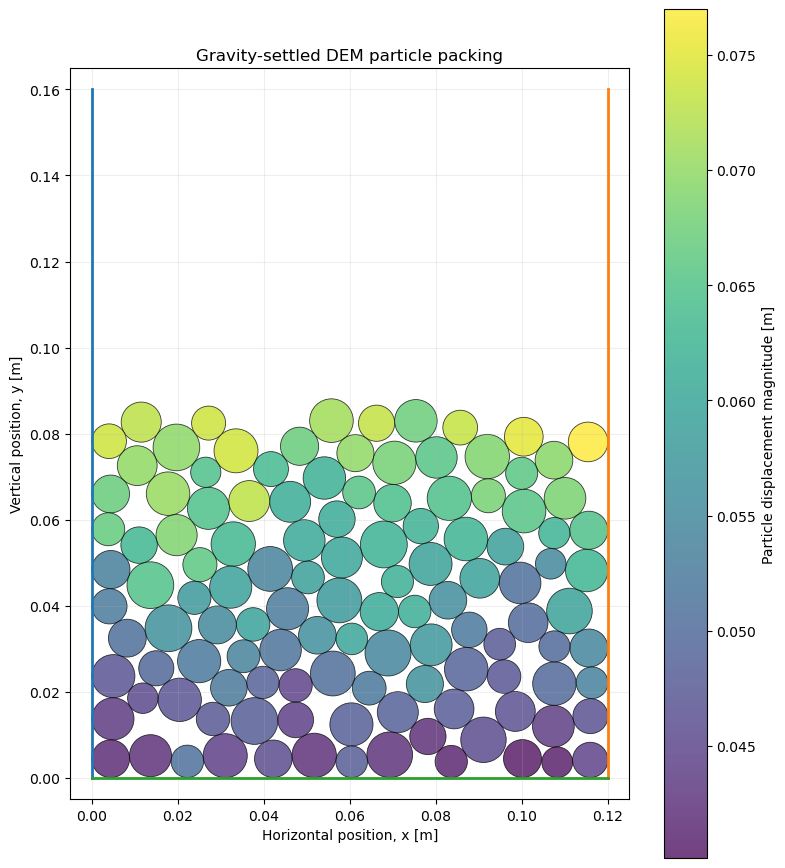

In [9]:
particle_displacements = (
    positions - initial_positions
)

plot_particles(
    positions=positions,
    radii=radii,
    box_width=box_width,
    box_height=box_height,
    title="Gravity-settled DEM particle packing",
    displacement=particle_displacements,
    save_path=figure_directory / "02_settled_dem_packing.png",
)

In [10]:
history_dataframe = pd.DataFrame(
    {
        "time_s": time_history,
        "kinetic_energy_J": kinetic_energy_history,
        "maximum_velocity_m_per_s": maximum_velocity_history,
        "coordination_number": coordination_number_history,
        "particle_contact_count": contact_count_history,
        "maximum_overlap_m": maximum_overlap_history,
    }
)

history_dataframe.head()

,time_s,kinetic_energy_J,maximum_velocity_m_per_s,coordination_number,particle_contact_count,maximum_overlap_m
0,0.000,3.942522e-09,0.000196,0.0,0,0.0
1,0.002,3.826389e-05,0.019319,0.0,0,0.0
2,0.004,1.442420e-04,0.037509,0.0,0,0.0
3,0.006,3.080113e-04,0.054812,0.0,0,0.0
4,0.008,5.207597e-04,0.071271,0.0,0,0.0


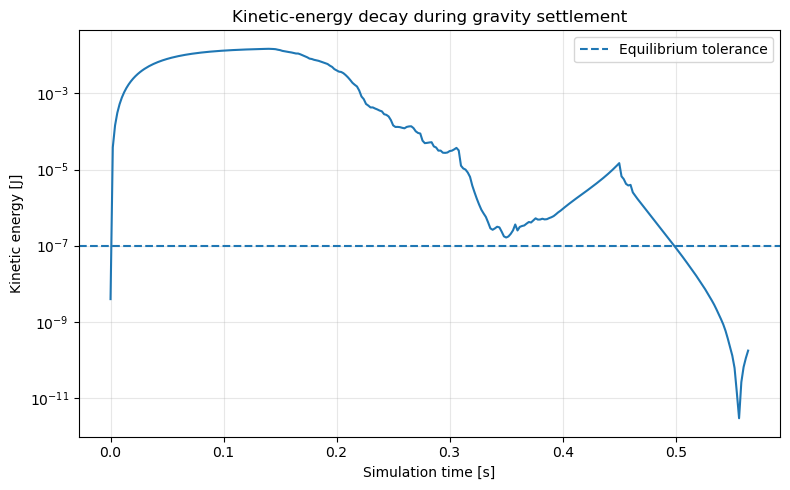

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogy(
    history_dataframe["time_s"],
    history_dataframe["kinetic_energy_J"],
)

ax.axhline(
    kinetic_energy_tolerance,
    linestyle="--",
    label="Equilibrium tolerance",
)

ax.set_xlabel("Simulation time [s]")
ax.set_ylabel("Kinetic energy [J]")
ax.set_title("Kinetic-energy decay during gravity settlement")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

plt.savefig(
    figure_directory / "03_kinetic_energy_history.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

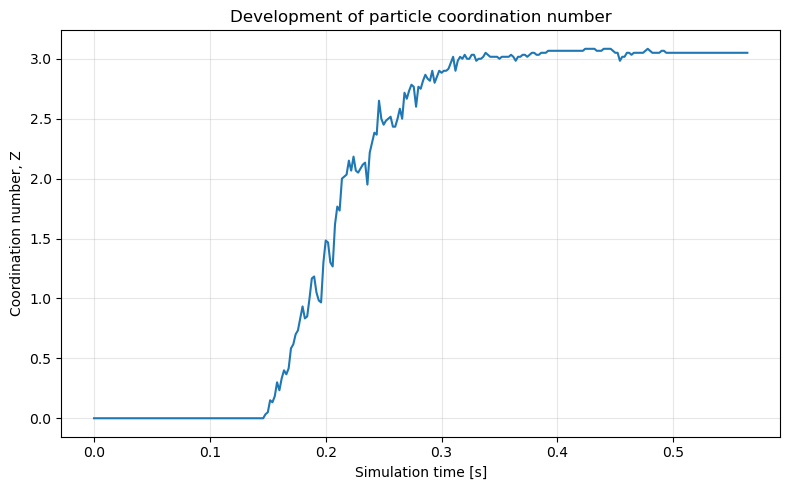

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    history_dataframe["time_s"],
    history_dataframe["coordination_number"],
)

ax.set_xlabel("Simulation time [s]")
ax.set_ylabel("Coordination number, Z")
ax.set_title("Development of particle coordination number")
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    figure_directory / "04_coordination_number_history.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

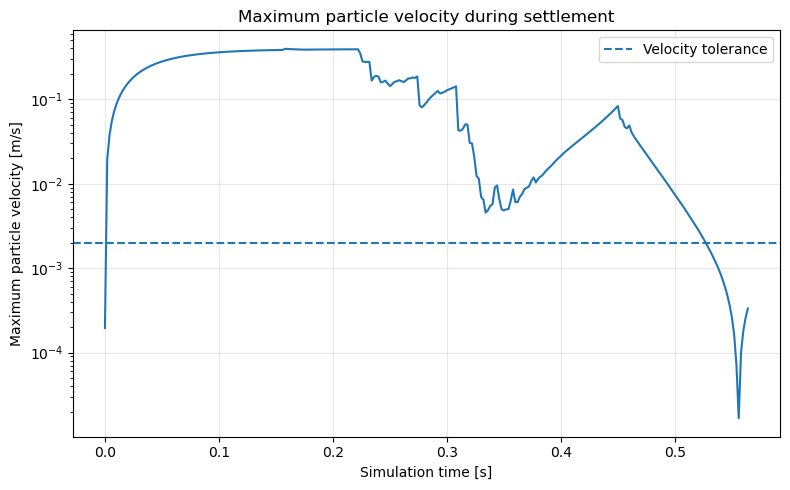

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogy(
    history_dataframe["time_s"],
    history_dataframe["maximum_velocity_m_per_s"],
)

ax.axhline(
    maximum_velocity_tolerance,
    linestyle="--",
    label="Velocity tolerance",
)

ax.set_xlabel("Simulation time [s]")
ax.set_ylabel("Maximum particle velocity [m/s]")
ax.set_title("Maximum particle velocity during settlement")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

plt.savefig(
    figure_directory / "05_maximum_velocity_history.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

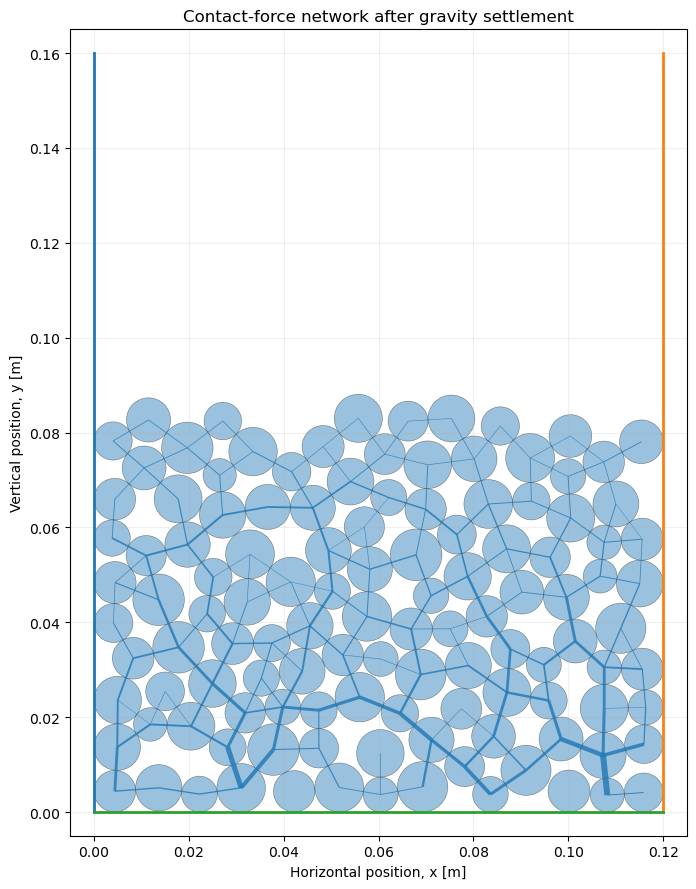

In [14]:
def plot_force_chain_network(
    positions,
    radii,
    contact_information,
    box_width,
    box_height,
    save_path=None,
):
    fig, ax = plt.subplots(figsize=(8, 9))

    circles = [
        Circle(
            (positions[i, 0], positions[i, 1]),
            radii[i],
        )
        for i in range(len(radii))
    ]

    particle_collection = PatchCollection(
        circles,
        edgecolor="black",
        linewidth=0.4,
        alpha=0.45,
    )

    ax.add_collection(particle_collection)

    if contact_information:
        normal_forces = np.array(
            [
                contact["normal_force"]
                for contact in contact_information
            ]
        )

        maximum_force = max(
            normal_forces.max(),
            1.0e-12,
        )

        line_segments = []
        line_widths = []

        for contact in contact_information:
            i = contact["particle_i"]
            j = contact["particle_j"]

            line_segments.append(
                [
                    positions[i],
                    positions[j],
                ]
            )

            relative_force = (
                contact["normal_force"]
                / maximum_force
            )

            line_widths.append(
                0.3 + 4.0 * relative_force
            )

        line_collection = LineCollection(
            line_segments,
            linewidths=line_widths,
            alpha=0.8,
        )

        ax.add_collection(line_collection)

    ax.plot(
        [0, 0],
        [0, box_height],
        linewidth=2,
    )

    ax.plot(
        [box_width, box_width],
        [0, box_height],
        linewidth=2,
    )

    ax.plot(
        [0, box_width],
        [0, 0],
        linewidth=2,
    )

    ax.set_xlim(-0.005, box_width + 0.005)
    ax.set_ylim(-0.005, box_height + 0.005)

    ax.set_aspect("equal")
    ax.set_xlabel("Horizontal position, x [m]")
    ax.set_ylabel("Vertical position, y [m]")
    ax.set_title("Contact-force network after gravity settlement")
    ax.grid(alpha=0.2)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()


plot_force_chain_network(
    positions=positions,
    radii=radii,
    contact_information=last_contact_information,
    box_width=box_width,
    box_height=box_height,
    save_path=figure_directory / "06_gravity_force_chain_network.png",
)

In [15]:
settled_particle_dataframe = pd.DataFrame(
    {
        "particle_id": np.arange(number_of_particles),
        "x_m": positions[:, 0],
        "y_m": positions[:, 1],
        "radius_m": radii,
        "mass_kg": masses,
        "velocity_x_m_per_s": velocities[:, 0],
        "velocity_y_m_per_s": velocities[:, 1],
        "angle_rad": angles,
        "angular_velocity_rad_per_s": angular_velocities,
        "displacement_x_m": particle_displacements[:, 0],
        "displacement_y_m": particle_displacements[:, 1],
    }
)

particle_csv_path = (
    csv_directory / "settled_particle_packing.csv"
)

history_csv_path = (
    csv_directory / "gravity_settlement_history.csv"
)

restart_file_path = (
    restart_directory / "settled_particle_packing.npz"
)

settled_particle_dataframe.to_csv(
    particle_csv_path,
    index=False,
)

history_dataframe.to_csv(
    history_csv_path,
    index=False,
)

np.savez(
    restart_file_path,
    positions=positions,
    initial_positions=initial_positions,
    velocities=velocities,
    radii=radii,
    masses=masses,
    angles=angles,
    angular_velocities=angular_velocities,
    moments_of_inertia=moments_of_inertia,
    box_width=box_width,
    box_height=box_height,
    particle_density=particle_density,
    particle_thickness=particle_thickness,
    normal_stiffness=normal_stiffness,
    tangential_stiffness=tangential_stiffness,
    normal_damping=normal_damping,
    tangential_damping=tangential_damping,
    particle_friction=particle_friction,
    wall_friction=wall_friction,
    equilibrium_reached=equilibrium_reached,
    final_coordination_number=final_coordination_number,
    final_kinetic_energy=final_kinetic_energy,
)

print("Files saved successfully.")
print()
print("Particle CSV:")
print(particle_csv_path)
print()
print("Settlement-history CSV:")
print(history_csv_path)
print()
print("Restart file:")
print(restart_file_path)

Files saved successfully.

Particle CSV:
C:\Users\duaas\dike_fem_dem_project\results\csv\settled_particle_packing.csv

Settlement-history CSV:
C:\Users\duaas\dike_fem_dem_project\results\csv\gravity_settlement_history.csv

Restart file:
C:\Users\duaas\dike_fem_dem_project\results\restart\settled_particle_packing.npz


In [16]:
print("NOTEBOOK 01 COMPLETION SUMMARY")
print("=" * 55)
print(f"Particles generated        : {number_of_particles}")
print(f"Equilibrium reached        : {equilibrium_reached}")
print(f"Final packing height       : {packing_height:.4f} m")
print(f"Final coordination number  : {final_coordination_number:.3f}")
print(f"Estimated area fraction    : {area_fraction:.3f}")
print(f"Final kinetic energy       : {final_kinetic_energy:.4e} J")
print(f"Maximum velocity           : {final_maximum_velocity:.4e} m/s")
print(f"Relative maximum overlap   : {relative_maximum_overlap:.3%}")
print()
print("The settled particle state has been saved for Notebook 02.")

NOTEBOOK 01 COMPLETION SUMMARY
Particles generated        : 120
Equilibrium reached        : True
Final packing height       : 0.0881 m
Final coordination number  : 3.050
Estimated area fraction    : 0.732
Final kinetic energy       : 2.1512e-10 J
Maximum velocity           : 3.6914e-04 m/s
Relative maximum overlap   : 0.608%

The settled particle state has been saved for Notebook 02.
